## Imports
The following libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
# Retail Price Estimation

## Business Analytics Internship

### Objective
#The objective of this project is to analyze retail product pricing factors and build a machine learning model to estimate product selling prices. The insights can help businesses optimize pricing strategies while remaining competitive and profitable.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

In [3]:
# Load the dataset into a pandas DataFrame
data = pd.read_csv(r"D:\BA_Internship\Task-2\data\retail_price.csv")

data.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [4]:
# Perform initial data exploration
print("Shape:", data.shape)

print("\nColumns:")
print(data.columns)

print("\nInfo:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

display(data.head())

Shape: (676, 30)

Columns:
Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    str    
 1   product_category_name       676 non-null    str    
 2   month_year                  676 non-null    str    
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price            

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [5]:
# Handle missing values and clean the dataset
data.isnull().sum()

product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
dtype: int64

In [6]:
features = [
    "qty",
    "freight_price",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "lag_price"
]

X = data[features]
y = data["unit_price"]

In [7]:
# Handle missing values and clean the dataset
X = X.fillna(X.mean(numeric_only=True))

In [8]:
# Import required libraries
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Import required libraries
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Generate predictions using the trained model
predictions = model.predict(X_test)

In [11]:
# Import required libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R² Score:", r2_score(y_test, predictions))

MAE : 3.7157222422411884
RMSE: 7.907164563326245
R² Score: 0.988426536806935


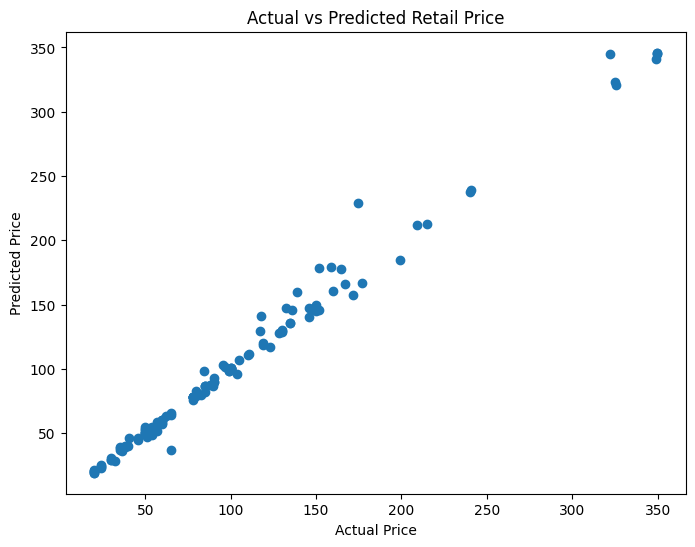

In [12]:
# Visualize the data and analysis results
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Retail Price")

plt.show()

# Business Insights

- Product pricing is influenced by multiple factors such as quantity sold, freight cost, product weight, and historical pricing.
- Historical prices (lag_price) are strong indicators for future pricing decisions.
- Competitor pricing helps businesses maintain market competitiveness.
- Predictive models enable retailers to make informed pricing decisions instead of relying solely on intuition.

# Recommendations

1. Monitor competitor pricing regularly.
2. Use predictive analytics before changing product prices.
3. Adjust pricing based on demand and historical sales.
4. Review freight costs to improve pricing efficiency.
5. Continuously retrain the prediction model using new sales data.

# Conclusion

This project successfully predicts retail product prices using machine learning techniques. The analysis demonstrates how predictive analytics supports pricing strategy, improves competitiveness, and enables data-driven business decisions.

# RetailIQ Module 2 – Pricing Advisor

## The original internship task predicts retail prices using machine learning.

###RetailIQ extends this by providing pricing recommendations that help business managers make pricing decisions instead of only viewing model predictions.

In [13]:
print("="*70)
print("            RetailIQ - Pricing Advisor")
print("="*70)

avg_price = data["unit_price"].mean()
avg_competitor = data["comp_1"].mean()

print(f"\nAverage Product Price      : ₹{avg_price:.2f}")
print(f"Average Competitor Price   : ₹{avg_competitor:.2f}")

if avg_price < avg_competitor:
    decision = "Increase Price Slightly"
    reason = "Competitor pricing is higher."
elif avg_price > avg_competitor:
    decision = "Maintain or Reduce Price"
    reason = "Current pricing is already above competitors."
else:
    decision = "Maintain Current Price"
    reason = "Pricing is aligned with competitors."

print("\nPricing Recommendation")
print("----------------------")
print("Decision :", decision)
print("Reason   :", reason)

print("\nExpected Business Impact")
print("------------------------")
print("✓ Competitive pricing")
print("✓ Better profitability")
print("✓ Improved customer retention")

            RetailIQ - Pricing Advisor

Average Product Price      : ₹106.50
Average Competitor Price   : ₹79.45

Pricing Recommendation
----------------------
Decision : Maintain or Reduce Price
Reason   : Current pricing is already above competitors.

Expected Business Impact
------------------------
✓ Competitive pricing
✓ Better profitability
✓ Improved customer retention


# Business Value Generated

RetailIQ converts predicted prices into pricing decisions.

Instead of only forecasting prices, the system helps decision-makers determine whether prices should be increased, maintained, or reduced based on competitor pricing.

# Innovation Added

The internship task focused on predicting retail prices.

RetailIQ extends this by introducing a Pricing Advisor that transforms predictions into business decisions, supporting pricing strategy and revenue optimization.

# Future Scope

- Dynamic pricing using real-time competitor data.
- AI-powered discount optimization.
- Seasonal pricing recommendations.
- Demand-based price forecasting.
- Integration with ERP and billing systems.